Convert raw PTB-XL ECG signals into clean NumPy arrays ready for deep learning.

In [6]:
!pip -q install kaggle wfdb

In [7]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

plt.style.use("ggplot")
!kaggle datasets download \
-d khyeh0719/ptb-xl-dataset \
-p /content/ptbxl \
--unzip

Dataset URL: https://www.kaggle.com/datasets/khyeh0719/ptb-xl-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.72G/1.72G [00:13<00:00, 141MB/s]



In [8]:
uploaded = files.upload()
from google.colab import files

uploaded = files.upload()      # upload kaggle.json
metadata = pd.read_csv("06_ecg_subset_metadata.csv")

print(metadata.shape)

metadata.head()

Saving 06_ecg_subset_metadata.csv to 06_ecg_subset_metadata (1).csv


Saving kaggle.json to kaggle.json
(5000, 6)


,ecg_id,patient_id,filename_lr,filename_hr,diagnostic_superclass,target_binary
0,9625,18700.0,records100/09000/09625_lr,records500/09000/09625_hr,['NORM'],0
1,15843,8908.0,records100/15000/15843_lr,records500/15000/15843_hr,['MI'],1
2,2961,2236.0,records100/02000/02961_lr,records500/02000/02961_hr,['NORM'],0
3,13763,9227.0,records100/13000/13763_lr,records500/13000/13763_hr,['MI'],1
4,3725,11961.0,records100/03000/03725_lr,records500/03000/03725_hr,['CD'],1


In [9]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print(os.listdir("/content/ptbxl"))

['ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1']


In [10]:
base_path = "/content/ptbxl"

dataset_folder = os.listdir(base_path)[0]

ptbxl_path = os.path.join(
    base_path,
    dataset_folder
)

print(ptbxl_path)

/content/ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1


In [13]:
sample_record = metadata.iloc[0]

signal_path = os.path.join(
    ptbxl_path,
    sample_record["filename_lr"]
)

signal, fields = wfdb.rdsamp(signal_path)

print(signal.shape)

print(fields)

(1000, 12)
{'fs': 100, 'sig_len': 1000, 'n_sig': 12, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], 'comments': []}


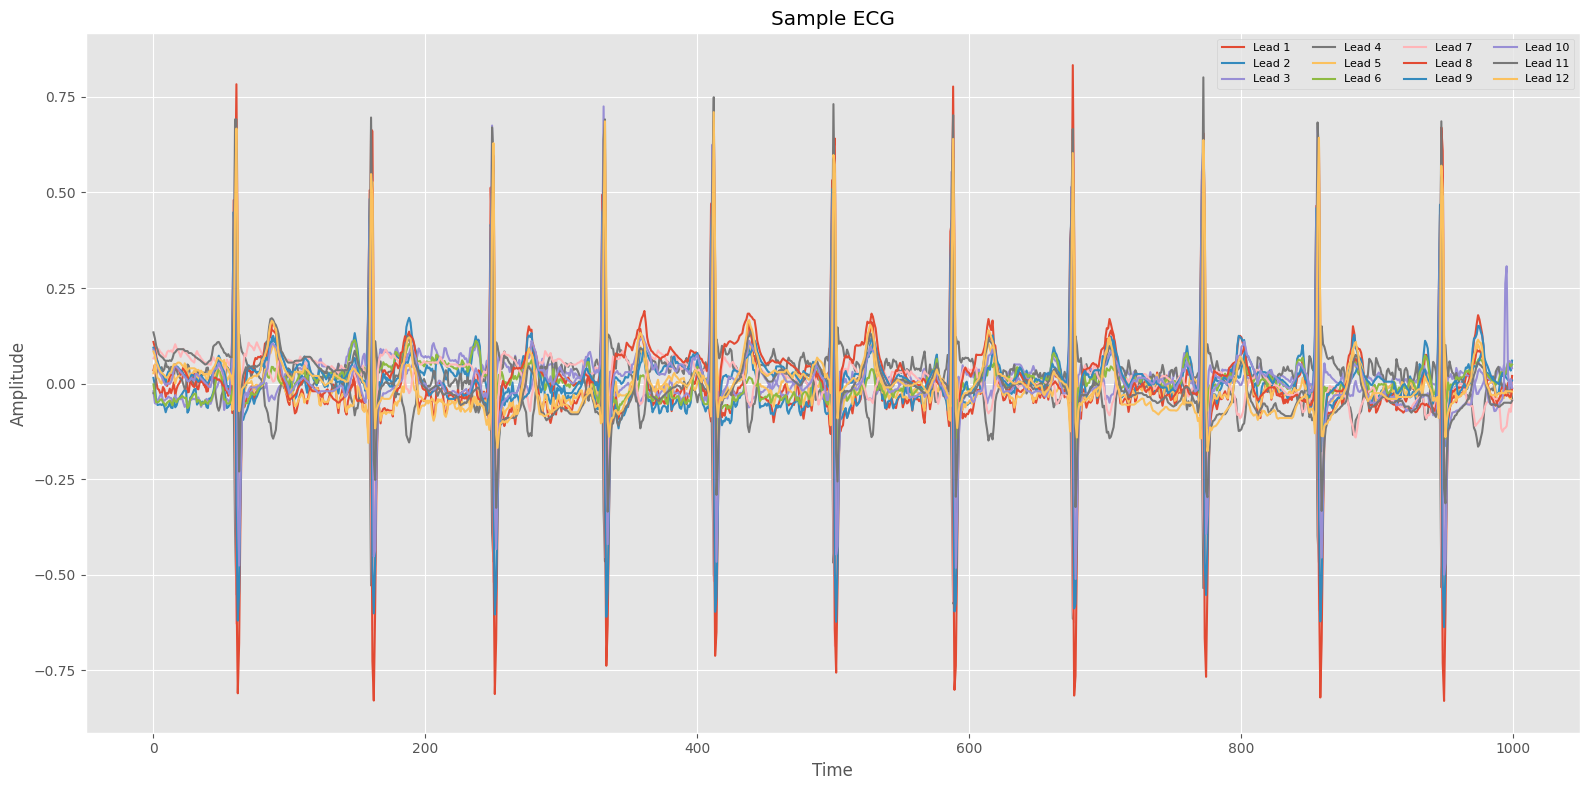

In [14]:
plt.figure(figsize=(16,8))

for i in range(signal.shape[1]):

    plt.plot(
        signal[:, i],
        label=f"Lead {i+1}"
    )

plt.title("Sample ECG")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.legend(
    ncol=4,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "07_sample_ecg.png",
    dpi=300
)

plt.show()

In [15]:
signal_lengths = []

for filename in metadata["filename_lr"]:

    path = os.path.join(
        ptbxl_path,
        filename
    )

    sig, _ = wfdb.rdsamp(path)

    signal_lengths.append(sig.shape)

length_df = pd.Series(signal_lengths)

print(length_df.value_counts())

(1000, 12)    5000
Name: count, dtype: int64


In [16]:
X_ecg = []
y_ecg = []
patient_ids = []

print("Loading ECG signals...\n")

for idx, row in metadata.iterrows():

    signal_path = os.path.join(
        ptbxl_path,
        row["filename_lr"]
    )

    signal, _ = wfdb.rdsamp(signal_path)

    X_ecg.append(signal)
    y_ecg.append(row["target_binary"])
    patient_ids.append(row["patient_id"])

    if (idx + 1) % 500 == 0:
        print(f"{idx+1} ECGs loaded")

print("\nFinished loading ECG dataset.")

Loading ECG signals...

500 ECGs loaded
1000 ECGs loaded
1500 ECGs loaded
2000 ECGs loaded
2500 ECGs loaded
3000 ECGs loaded
3500 ECGs loaded
4000 ECGs loaded
4500 ECGs loaded
5000 ECGs loaded

Finished loading ECG dataset.


In [17]:
X_ecg = np.array(X_ecg, dtype=np.float32)
y_ecg = np.array(y_ecg, dtype=np.int32)
patient_ids = np.array(patient_ids)

print("ECG Shape :", X_ecg.shape)
print("Labels    :", y_ecg.shape)
print("Patients  :", patient_ids.shape)

ECG Shape : (5000, 1000, 12)
Labels    : (5000,)
Patients  : (5000,)


In [18]:
X_mean = X_ecg.mean(axis=1, keepdims=True)
X_std = X_ecg.std(axis=1, keepdims=True)

X_ecg = (X_ecg - X_mean) / (X_std + 1e-8)

print("Normalization complete.")

Normalization complete.


In [19]:
print("Mean :", np.mean(X_ecg))
print("Std  :", np.std(X_ecg))

print()

print("Minimum :", np.min(X_ecg))
print("Maximum :", np.max(X_ecg))

Mean : 1.592954e-10
Std  : 1.0000002

Minimum : -27.878325
Maximum : 25.161314


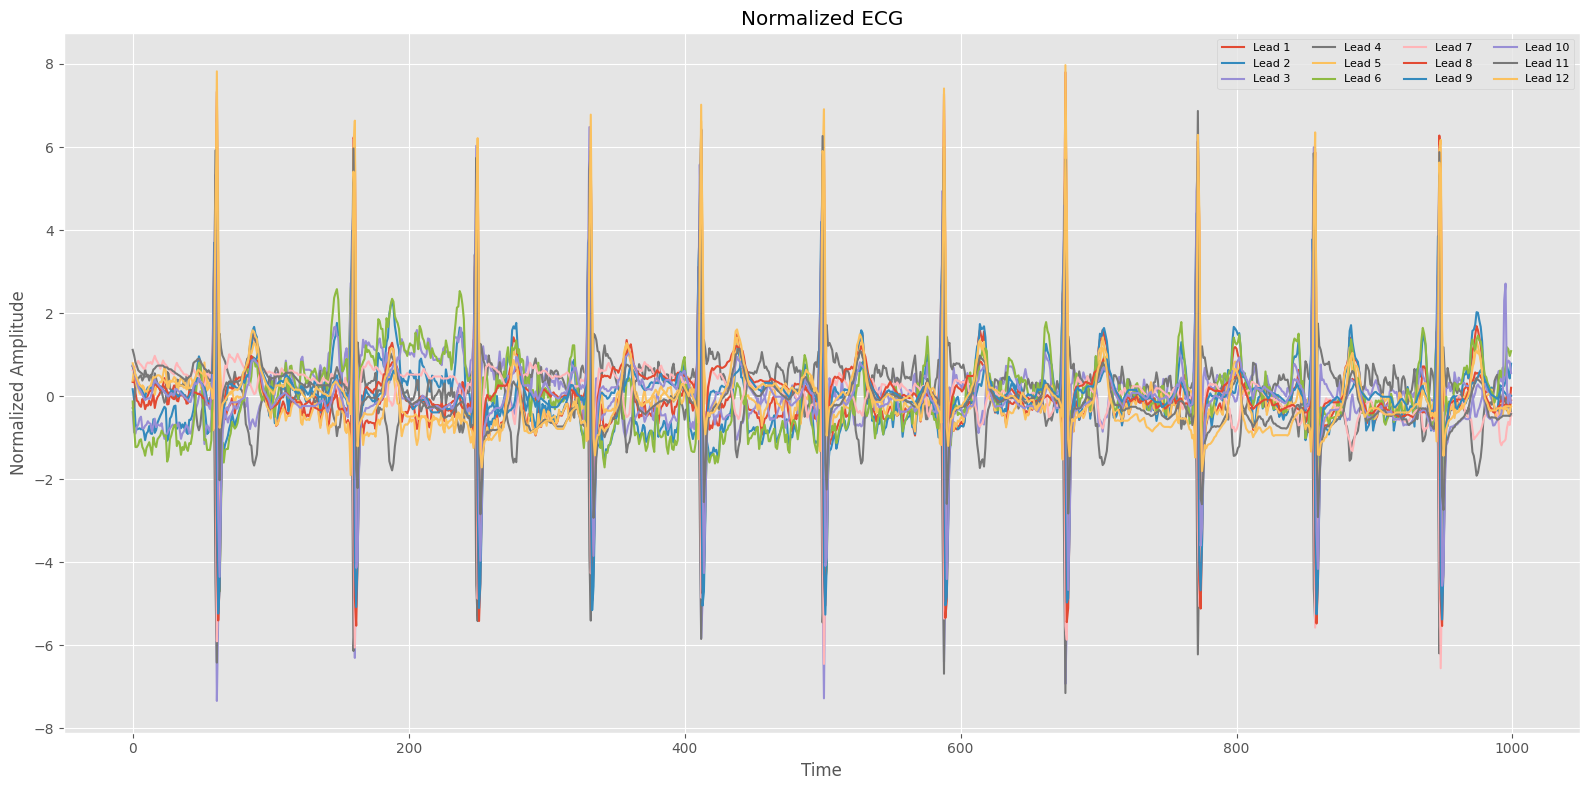

In [20]:
sample = 0

plt.figure(figsize=(16,8))

for lead in range(12):

    plt.plot(
        X_ecg[sample, :, lead],
        label=f"Lead {lead+1}"
    )

plt.title("Normalized ECG")

plt.xlabel("Time")

plt.ylabel("Normalized Amplitude")

plt.legend(
    ncol=4,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "07_normalized_ecg.png",
    dpi=300
)

plt.show()

In [21]:
np.save("07_X_ecg.npy", X_ecg)
np.save("07_y_ecg.npy", y_ecg)
np.save("07_patient_ids.npy", patient_ids)

print("Processed ECG arrays saved.")

Processed ECG arrays saved.


In [22]:
stats_df = pd.DataFrame({
    "Metric": [
        "Total ECGs",
        "Time Samples",
        "ECG Leads",
        "Unique Patients",
        "Healthy",
        "Disease"
    ],
    "Value": [
        X_ecg.shape[0],
        X_ecg.shape[1],
        X_ecg.shape[2],
        len(np.unique(patient_ids)),
        np.sum(y_ecg == 0),
        np.sum(y_ecg == 1)
    ]
})

stats_df

,Metric,Value
0,Total ECGs,5000
1,Time Samples,1000
2,ECG Leads,12
3,Unique Patients,4807
4,Healthy,2119
5,Disease,2881


In [23]:
stats_df.to_csv(
    "07_signal_statistics.csv",
    index=False
)

In [25]:
from google.colab import files

download_files = [
    "07_X_ecg.npy",
    "07_y_ecg.npy",
    "07_patient_ids.npy",
    "07_signal_statistics.csv",
    "07_sample_ecg.png",
    "07_normalized_ecg.png"
]

for file in download_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notebook Summary

Successfully processed the PTB-XL development subset.

Outputs generated:
- 07_X_ecg.npy
- 07_y_ecg.npy
- 07_patient_ids.npy
- 07_signal_statistics.csv
- 07_sample_ecg.png
- 07_normalized_ecg.png

These files will serve as the input to Notebook 08 (CNN-LSTM ECG Classification).